# Before your start:

    Read the README.md file
    Comment as much as you can and use the resources (README.md file)
    Happy learning!

*Notes:* 

- Solve the questions with python.

- Round the final answer to three decimal places.

In [1]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import math

## Bernoulli's Distribution

In a basket containing 100 fruits, there are 60 apples and 40 oranges. 

A fruit is picked randomly from the basket. 

1. **What is the probability that the fruit is apple?**
1. **What is the probability that it is an orange?**

In [4]:
"""
Calculate:
p = probability that the fruit is an apple 
q = probability that the fruit is an orange
"""
total = 100
number_oranges = 40
number_apples = 60

#1
p = number_apples/total

#2
q = number_oranges/total

print(p, q)

p + q == 1     # must hold (and it does in this case)

0.6 0.4


True

This is a Bernoulli experiment since there are only 2 possible outcomes (success/failure).

Now we take a random sample of 20 fruits from the basket. After each fruit is taken, a new fruit of the same type is replaced in the basket. Therefore, every time we are taking 1 fruit from 100 fruits. 

1. **What is the probability that the first 5 fruits are all apples?**

1. **What is the probability that the first 5 fruits are all apples and the next 15 fruits are all oranges?**

You can include the `p` and `q` probabilities you previous calculated in your solution.

Order matters in this case!

In [ ]:
# What is the probability that the first 5 fruits are all apples?

# 1

probability_5_apples = p ** 5    #each draw does not affect the next, which implies independence, hence p to the n draws (5 in this case)
print(probability_5_apples)

# 2

probability_5_apples_15_oranges = p ** 5 * q ** 15    #each draw does not affect the next, which implies independence, hence p to the n draws (5 in this case) and q to the k draws (15)
print(probability_5_apples_15_oranges)


0.07775999999999998
8.349416423424006e-08


## Binomial Distribution

Similar to the above problem, this time again we randomly sample 20 fruits.

**What is the probability that this time the sample contains 5 apples and 15 oranges?**

Please note that this time the order of the fruits being picked does not matter.

- n = number of trials
- p = probability of success
- k = number of successes

Order does not matter here, hence 20 choose 5, i.e, how many ways can one arrange 5 apples in 20 picks? This hints into the use of combinations.

So this is a Binomial Probability Mass Function (PMF).

In [ ]:
from scipy.stats import binom

n = 20    # total fruits picked
k = 5    # number of apples
p = number_apples/total

prob = binom.pmf(k, n, p)
print(prob)


0.0012944935222876583


In [10]:
x = 20    # total number of fruits sampled
y = 5     # number of apples in the 20-fruit sample
z = x - y   # number of oranges in the 20-fruit sample

p = number_apples/total    # probability of apples
q = 1 - p      # probability of oranges

# Apples considered as success:
prob_apples = binom.pmf(y, x, p)

# Oranges considered as success:
prob_oranges = binom.pmf(z, x, q)

print(prob_apples, prob_oranges)    # mathematically the same, given the nature of the experiment

0.0012944935222876583 0.0012944935222876583


In the lesson we also discussed CDF (cumulative distribution function). In the context of the above problem, **what is the probability that less than 5 fruits picked are apples?**

Write the formula and calculate the probability below.

In [ ]:
# Less than 5 fruits picked are apples:

a = 5   # number of fruits picked 
x = 20   # total number of fruits sampled
p = number_apples/total

prob_lessthan_5apples = binom.pmf(a-1, x, p)    #a-1 because it's less than 5 fruits picked being apples
print(prob_lessthan_5apples)

0.0002696861504765956


<!-- **Plot the PDF (probability distributiom function) for the above binomial distribution.** -->

**Plot the Probability Mass Function (PMF) for the above binomial distribution.**

*Hint: The range of x in a binomial distribution is from `0` to `n`.*

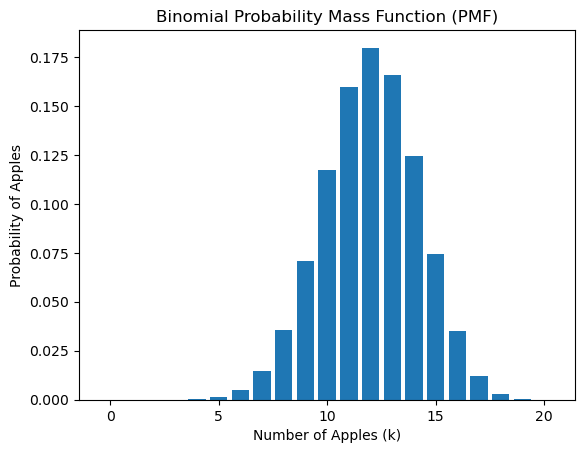

In [18]:
n = 20    # sample size (20 trials)
p = number_apples/total

k_values = np.arange(0, n + 1)
pmf_values = binom.pmf(k_values, n, p)

plt.bar(k_values, pmf_values)
plt.xlabel("Number of Apples (k)")
plt.ylabel("Probability of Apples")
plt.title("Binomial Probability Mass Function (PMF)")
plt.show()

Here, we see that p (0.6) > 0.5, meaning that the distribution is skewed left (more high values).

For reference:

- p ≈ 0.5 - symmetric (centered)
- p < 0.5 - skewed right (more low values)

## Poisson Distribution

In this challenge you are required to use the Math library in python to solve the problems.

In the UEFA champions league tournament, the average number of goals scored in a match is 2.3. 

**What is the probability that the number of goals scored in a match is 5?**

*Hint: Use the exp() in the math library*

And to calculate the factorial, you can use the following code:

```python
import math
math.factorial(n) # n is the number you want to find the factorial of
```

In [ ]:
# Applying the Poisson Distribution formula:

lam = 2.3   # average number of goals socred in a match
k = 5     # goals in the question

prob_5goals = (lam**k * math.exp(-lam)) / math.factorial(k)
print(prob_5goals)

0.0537750255819468


**Draw a poisson probability distribution plot for the number of goals to be between 0 to 10.**

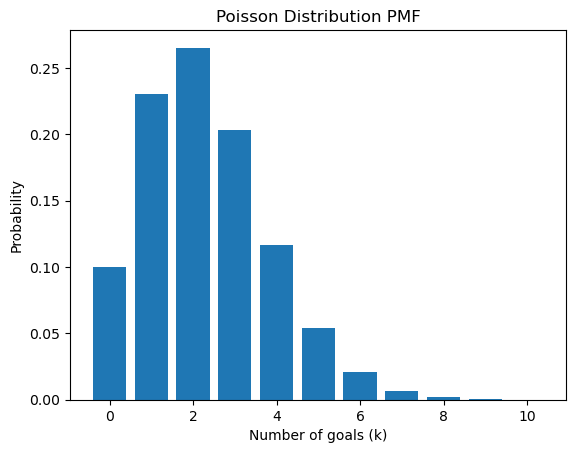

In [ ]:
# your code here
# Please label the axes and give a title to the plot 

from scipy.stats import poisson

lam = 2.3   # average number of goals socred in a match
n = 10    # specified number of goals

k_values = np.arange(0, n + 1)      #enforcing n+1 to include n itself, since the stop value is not included in arange
pmf_values = poisson.pmf(k_values, lam)

plt.bar(k_values, pmf_values)
plt.xlabel("Number of goals (k)")
plt.ylabel("Probability")
plt.title("Poisson Distribution PMF")
plt.show()